In [1]:
# Install YOLOv5
!pip install ultralytics

In [3]:
import shutil

# Copy the data.yaml file to a writable location (e.g., /kaggle/working)
shutil.copy("/kaggle/input/yolo-apple-final/Apple-Disease-Detection.v1i.yolov8/data.yaml", "/kaggle/working/data.yaml")

'/kaggle/working/data.yaml'

In [6]:
# Define the new content for the data.yaml file
new_yaml_content = """
train: /kaggle/input/yolo-apple-final/Apple-Disease-Detection.v1i.yolov8/train
val: /kaggle/input/yolo-apple-final/Apple-Disease-Detection.v1i.yolov8/valid
test: /kaggle/input/yolo-apple-final/Apple-Disease-Detection.v1i.yolov8/test
nc: 4
names: ['BLOTCH', 'HEALTHY', 'ROT', 'SCAB']
"""

# Write the new content to the data.yaml file
with open("/kaggle/working/data.yaml", "w") as file:
    file.write(new_yaml_content)

In [7]:
# Read the updated data.yaml file
with open("/kaggle/working/data.yaml", "r") as file:
    print(file.read())


train: /kaggle/input/yolo-apple-final/Apple-Disease-Detection.v1i.yolov8/train
val: /kaggle/input/yolo-apple-final/Apple-Disease-Detection.v1i.yolov8/valid
test: /kaggle/input/yolo-apple-final/Apple-Disease-Detection.v1i.yolov8/test
nc: 4
names: ['BLOTCH', 'HEALTHY', 'ROT', 'SCAB']



In [8]:
from ultralytics import YOLO

# Load a YOLOv8 detection model
model = YOLO("yolov8s.pt")  # Use a YOLOv8 detection model (e.g., yolov8s, yolov8m, yolov8l)

# Train the model
results = model.train(
    data="/kaggle/working/data.yaml",  # Path to the dataset configuration file
    epochs=50,               # Number of epochs
    imgsz=640,               # Image size (640x640 is standard for detection)
    batch=16,                # Batch size (adjust based on GPU memory)
    optimizer="Adam",        # Optimizer (Adam, SGD, etc.)
    lr0=0.001,               # Initial learning rate
    weight_decay=0.0005,     # Weight decay for regularization
    dropout=0.2,             # Dropout for regularization
    augment=True,            # Enable data augmentation
    patience=10,             # Early stopping patience
    seed=42,                 # Random seed for reproducibility
    device="0",              # Use GPU (set to "cpu" if no GPU)
    workers=4,               # Number of data loading workers
)



Ultralytics 8.3.88 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/kaggle/working/data.yaml, epochs=50, time=None, patience=10, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=4, project=None, name=train5, exist_ok=False, pretrained=True, optimizer=Adam, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.2, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, sh

train: Scanning /kaggle/input/yolo-apple-final/Apple-Disease-Detection.v1i.yolov8/train/labels... 912 images, 3 backgrounds, 0 corrupt: 100%|██████████| 912/912 [00:02<00:00, 387.22it/s]

train: WARNING ⚠️ Cache directory /kaggle/input/yolo-apple-final/Apple-Disease-Detection.v1i.yolov8/train is not writeable, cache not saved.


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.5 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
val: Scanning /kaggle/input/yolo-apple-final/Apple-Disease-Detection.v1i.yolov8/valid/labels... 87 images, 0 backgrounds, 0 corrupt: 100%|██████████| 87/87 [00:00<00:00, 307.73it/s]

...

EarlyStopping: Training stopped early as no improvement observed in last 10 epochs. Best results observed at epoch 32, best model saved as best.pt.
To update EarlyStopping(patience=10) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

42 epochs completed in 0.218 hours.
Optimizer stripped from runs/detect/train5/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/train5/weights/best.pt, 22.5MB

Validating runs/detect/train5/weights/best.pt...
Ultralytics 8.3.88 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:01<00:00,  1.60it/s]


                   all         87        101      0.866      0.894      0.946      0.761
                BLOTCH         21         22      0.821      0.909      0.952      0.824
               HEALTHY         15         24      0.874      0.958      0.967      0.737
                   ROT         24         24      0.847      0.958      0.958      0.746
                  SCAB         28         31      0.921      0.751      0.908      0.736


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.2ms preprocess, 17.0ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs/detect/train5


Ultralytics 8.3.88 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)


val: Scanning /kaggle/input/yolo-apple-final/Apple-Disease-Detection.v1i.yolov8/valid/labels... 87 images, 0 backgrounds, 0 corrupt: 100%|██████████| 87/87 [00:00<00:00, 469.57it/s]

val: WARNING ⚠️ Cache directory /kaggle/input/yolo-apple-final/Apple-Disease-Detection.v1i.yolov8/valid is not writeable, cache not saved.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:02<00:00,  2.59it/s]


                   all         87        101      0.866      0.895      0.946       0.76
                BLOTCH         21         22      0.821      0.909      0.952      0.824
               HEALTHY         15         24      0.874      0.958      0.967      0.737
                   ROT         24         24      0.847      0.958      0.958      0.746
                  SCAB         28         31      0.921      0.753      0.908      0.736


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 3.5ms preprocess, 12.6ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to runs/detect/train55
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c3a2d82d1e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039

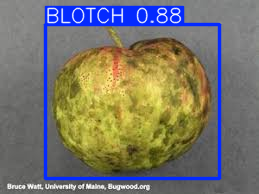

In [14]:
# Evaluate the model
metrics = model.val()  # Evaluate on the validation set
print(metrics)  # Print mAP, precision, recall, etc.

# Perform inference on a new image
results = model.predict("/kaggle/input/test-3/download (8).jpg")
for result in results:
    print(result.boxes)  # Bounding box predictions
    result.show()        # Show the image with predicted bounding boxes

In [17]:
import os

# Check where the trained model is stored
os.listdir("/kaggle/working/runs/detect")


['train53',
 'train2',
 'train3',
 'train52',
 'train54',
 'train5',
 'train55',
 'train4',
 'train']

In [18]:
import os

exp_dirs = os.listdir("/kaggle/working/runs/detect")
for exp in exp_dirs:
    model_path = f"/kaggle/working/runs/detect/{exp}/weights/best.pt"
    if os.path.exists(model_path):
        print(f"Found trained model: {model_path}")


Found trained model: /kaggle/working/runs/detect/train5/weights/best.pt


In [16]:
import os
import pandas as pd

# Directory containing all training runs
runs_dir = "/kaggle/working/runs/detect"

# Initialize variables to track the best run
best_mAP = 0
best_run = None

# Iterate through all runs
for run in os.listdir(runs_dir):
    run_path = os.path.join(runs_dir, run)
    results_file = os.path.join(run_path, "results.csv")

    if os.path.exists(results_file):
        # Load the results.csv file
        results = pd.read_csv(results_file)
        
        # Print column names for debugging
        print(f"Columns in {results_file}: {results.columns}")

        # Check if "metrics/mAP@0.5" is in the DataFrame
        if "metrics/mAP@0.5" in results.columns:
            last_mAP = results["metrics/mAP@0.5"].iloc[-1]

            # Update the best run if this run is better
            if last_mAP > best_mAP:
                best_mAP = last_mAP
                best_run = run
        else:
            print(f"⚠️ 'metrics/mAP@0.5' column not found in {results_file}")

# Print the best run
if best_run:
    print(f"✅ Best run: {best_run} with mAP@0.5: {best_mAP}")
    best_pt_path = os.path.join(runs_dir, best_run, "weights/best.pt")
    print(f"🔗 Path to best.pt: {best_pt_path}")
else:
    print("❌ No valid runs found with 'metrics/mAP@0.5'")


Columns in /kaggle/working/runs/detect/train5/results.csv: Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')
⚠️ 'metrics/mAP@0.5' column not found in /kaggle/working/runs/detect/train5/results.csv
❌ No valid runs found with 'metrics/mAP@0.5'
